In [1]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("../data/yellow_tripdata_2026.csv")
df

C:\Users\Linh\AppData\Local\Temp\ipykernel_13520\3963665272.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/yellow_tripdata_2026.csv")


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10483492,2,2026-03-31 23:10:43,2026-03-31 23:33:02,NaN,8.47,NaN,NaN,13,263,0,50.14,0.00,0.5,0.00,0.0,1.0,60.37,NaN,NaN,0.75
10483493,2,2026-03-31 23:41:22,2026-03-31 23:52:36,NaN,1.99,NaN,NaN,24,42,0,12.32,0.00,0.5,0.00,0.0,1.0,13.82,NaN,NaN,0.00
10483494,2,2026-03-31 23:39:38,2026-04-01 00:13:44,NaN,10.21,NaN,NaN,62,237,0,47.95,0.00,0.5,0.00,0.0,1.0,52.70,NaN,NaN,0.75
10483495,2,2026-03-31 23:57:57,2026-04-01 00:29:33,NaN,7.87,NaN,NaN,61,141,0,49.93,0.00,0.5,0.00,0.0,1.0,53.93,NaN,NaN,0.00


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10483497 entries, 0 to 10483496
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
 19  cbd_congestion_fee     float64
dtypes: float64(13), int64(4), object(3)
memory usage: 1.6+ GB


In [8]:
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)
df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

# Hour-of-day 

In [14]:
# Tạo feature pickup_hour
df_time = df.copy()

df_time["pickup_hour"] = (
    df_time["tpep_pickup_datetime"]
    .dt.hour
)


df_time["pickup_date"] = (
    df_time["tpep_pickup_datetime"]
    .dt.date
)

df_time["day_of_week"] = (
    df_time["tpep_pickup_datetime"]
    .dt.day_name()
)

In [6]:
# Số giờ theo chuyến đi
hourly_trips = (
    df_time
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trips")
)

hourly_trips

,pickup_hour,trips
0,0,324014
1,1,217973
2,2,144233
3,3,108846
4,4,89096
5,5,98313
6,6,188812
7,7,334424
8,8,439099
9,9,451111


In [ ]:
# Peak Hours
hourly_trips.sort_values(
    "trips",
    ascending=False
)


,pickup_hour,trips
18,18,695685
17,17,660305
21,21,646398
19,19,638501
20,20,638076
15,15,612943
16,16,592257
14,14,579739
22,22,579676
13,13,542482


In [ ]:
# Off-Peak
hourly_trips.sort_values(
    "trips"
)

,pickup_hour,trips
4,4,89096
5,5,98313
3,3,108846
2,2,144233
6,6,188812
1,1,217973
0,0,324014
7,7,334424
8,8,439099
23,23,443108


In [ ]:
# Morning Commute
df_time["period"] = "Other"

df_time.loc[
    df_time.pickup_hour.between(7,9),
    "period"
] = "Morning commute"
df_time["period"].value_counts()

period
Other              9258863
Morning commute    1224634
Name: count, dtype: int64

In [ ]:
# Evening Commute
df_time.loc[
    df_time.pickup_hour.between(16,19),
    "period"
] = "Evening commute"
df_time["period"].value_counts()

period
Other              6672115
Evening commute    2586748
Morning commute    1224634
Name: count, dtype: int64

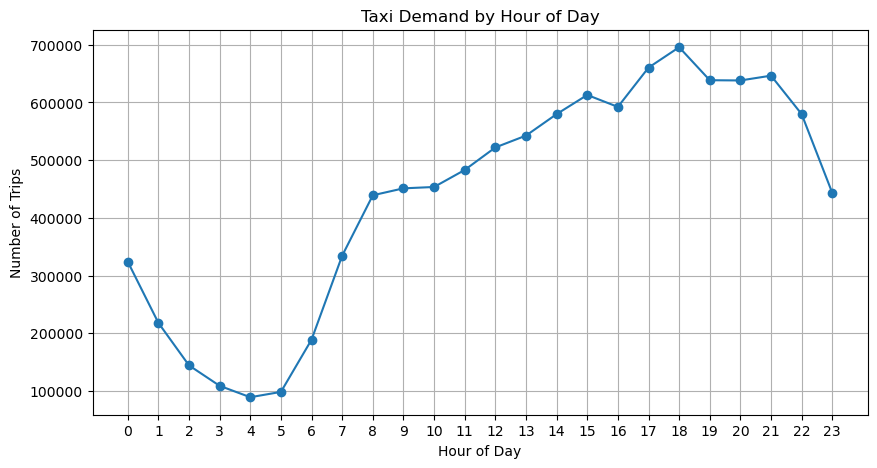

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    hourly_trips["pickup_hour"],
    hourly_trips["trips"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Hour of Day")

plt.xticks(range(24))
plt.grid(True)

plt.show()

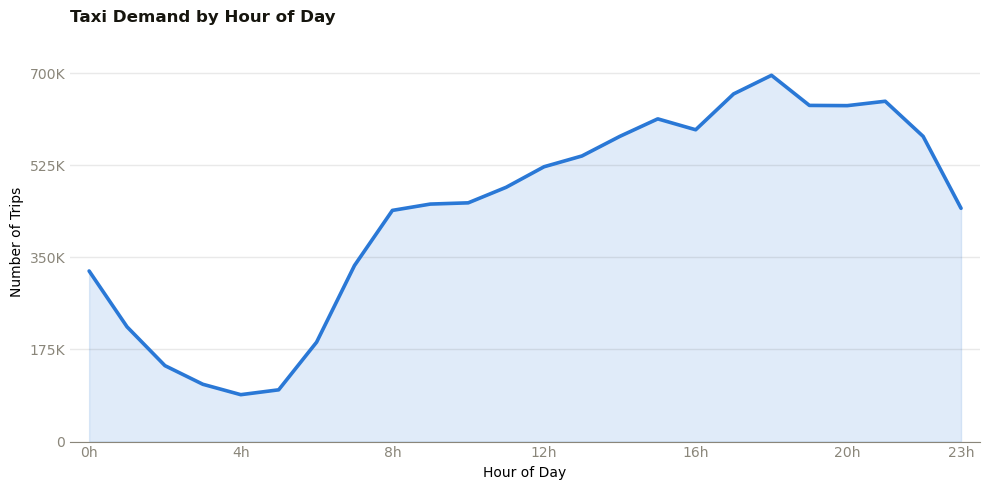

In [12]:
# Biểu đồ nhu cầu theo giờ — dạng area, nền trắng, màu xanh
import matplotlib.pyplot as plt

hours = hourly_trips["pickup_hour"].to_numpy()
trips = hourly_trips["trips"].to_numpy()

BLUE, INK, MUTED = "#2a78d6", "#16150E", "#8A867A"

fig, ax = plt.subplots(figsize=(10, 5))

# Vùng nền + đường
ax.fill_between(hours, trips, color=BLUE, alpha=0.14, zorder=1)
ax.plot(hours, trips, color=BLUE, linewidth=2.6, solid_capstyle="round", zorder=2)

# Trục & lưới
ax.set_title("Taxi Demand by Hour of Day", loc="left",
             color=INK, fontweight="bold", fontsize=12, pad=14)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
ax.set_yticks([0, 175000, 350000, 525000, 700000])
ax.set_yticklabels(["0", "175K", "350K", "525K", "700K"])
ax.set_xticks([0, 4, 8, 12, 16, 20, 23])
ax.set_xticklabels(["0h", "4h", "8h", "12h", "16h", "20h", "23h"])
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, 760000)

ax.grid(axis="y", color=INK, alpha=0.09, linewidth=1)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED, length=0)

plt.tight_layout()
plt.show()

#### Nhận xét:
1. Nhu cầu thay đổi rõ rệt theo thời gian trong ngày: Biểu đồ cho thấy số lượng chuyến đi không phân bố đồng đều trong 24 giờ. Sau nửa đêm, nhu cầu giảm mạnh và đạt mức thấp nhất vào rạng sáng, sau đó tăng nhanh từ buổi sáng và duy trì ở mức cao đến buổi tối.
2. Off-Peak Hours:
- Nhu cầu giảm liên tục từ 0h đến 4h.
- 4h sáng là thời điểm có số chuyến đi thấp nhất (khoảng 89096 chuyến).Sau 5h, lượng chuyến bắt đầu tăng trở lại.
- Khoảng 2h–5h sáng là thời gian off-peak, phản ánh nhu cầu di chuyển rất thấp trong khoảng thời gian rạng sáng
3. Peak Hours:
- Sau 8h, nhu cầu tiếp tục tăng.
- Đỉnh cao nhất xuất hiện vào khoảng 18h với 695685 chuyến.
- Khung giờ 17h–18h là thời điểm có nhu cầu sử dụng taxi cao nhất trong ngày.
4. Morning Commute:
- Từ 6h đến 8h, số chuyến tăng rất nhanh.
- Chỉ trong khoảng 5h → 8h, số chuyến tăng từ 98313 lên 439099.
- Nhu cầu tăng mạnh vào đầu buổi sáng, đặc biệt từ 6h đến 8h, cho thấy đây nhiều khả năng là giai đoạn người dân bắt đầu di chuyển đến nơi làm việc hoặc trường học.
5. Evening Commute:
- Từ 17h đến 21h, lượng chuyến luôn duy trì ở mức rất cao.
- Sau 22h, nhu cầu bắt đầu giảm nhanh.
- Buổi chiều tối có nhu cầu cao hơn buổi sáng và kéo dài trong nhiều giờ.

# Day-of-week 

In [16]:
# Ngày trong tuần
df["pickup_day"] = (
    df["tpep_pickup_datetime"]
    .dt.day_name()
)

In [17]:
df["day_type"] = np.where(
    df["tpep_pickup_datetime"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

In [18]:
day_demand = (
    df.groupby("pickup_day")
      .size()
      .reset_index(name="trips")
)
print(day_demand)

  pickup_day    trips
0     Friday  1632613
1     Monday  1183054
2   Saturday  1725731
3     Sunday  1353549
4   Thursday  1674882
5    Tuesday  1469479
6  Wednesday  1444189


In [11]:
week_type = (
    df.groupby("day_type")
      .size()
      .reset_index(name="trips")
)
print(week_type)

  day_type    trips
0  Weekday  7404217
1  Weekend  3079280


In [19]:
df["pickup_hour"] = (
    df["tpep_pickup_datetime"]
    .dt.hour
)

In [17]:
result = df.groupby(
    ["day_type","pickup_hour"]
).size()

In [24]:
result 

day_type  pickup_hour
Weekday   0              139959
          1               74492
          2               44760
          3               32842
          4               39349
          5               72264
          6              156025
          7              292912
          8              376692
          9              359138
          10             334711
          11             344749
          12             366833
          13             375914
          14             418142
          15             448187
          16             417239
          17             475222
          18             497418
          19             455158
          20             480884
          21             491807
          22             416185
          23             293335
Weekend   0              184055
          1              143481
          2               99473
          3               76004
          4               49747
          5               26049
          6       

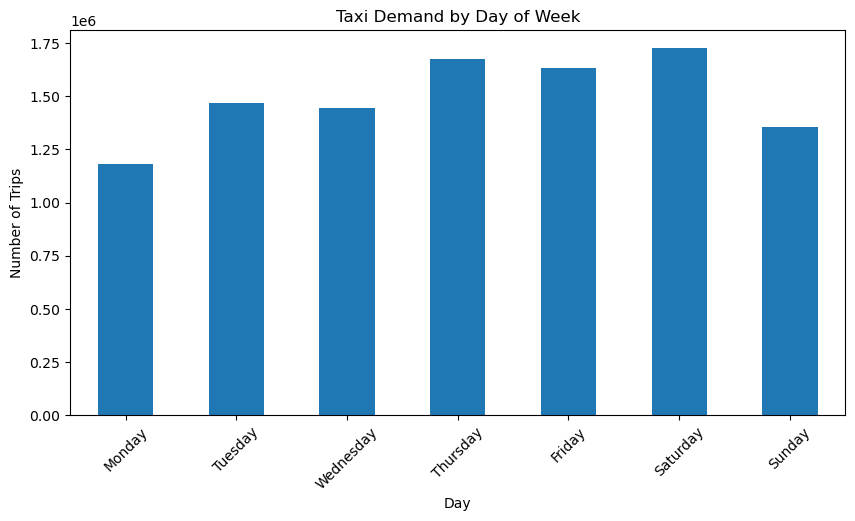

In [13]:
import matplotlib.pyplot as plt

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_demand = (
    df["pickup_day"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10,5))
day_demand.plot(kind="bar")

plt.title("Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.show()

#### Nhận xét:
1. Xu hướng trong tuần: Nhu cầu sử dụng taxi thay đổi theo từng ngày trong tuần và không phân bố đồng đều. Nhu cầu có xu hướng tăng dần từ đầu tuần đến cuối tuần, đạt đỉnh vào thứ Bảy trước khi giảm trở lại vào Chủ Nhật.
2. Ngày nào có nhu cầu cao nhất: 
- Thứ Bảy ghi nhận số lượng chuyến đi cao nhất trong tuần (1725731 chuyến)
- Sau đó là Thursday (1674882 chuyến)
- Tiếp theo là Friday (1632613 chuyến)
3. Thứ Hai có số chuyến đi thấp nhất trong tuần (1183054 chuyến)

In [ ]:
# Số chuyến theo từng ngày
daily_trips = (
    df.groupby(df["tpep_pickup_datetime"].dt.date)
      .size()
      .reset_index(name="trips")
)

daily_trips["day_type"] = pd.to_datetime(
    daily_trips["tpep_pickup_datetime"]
).dt.dayofweek.map(
    lambda x: "Weekday" if x < 5 else "Weekend"
)

In [11]:
# Trung bình
avg_daily = (
    daily_trips.groupby("day_type")["trips"]
    .mean()
    .reset_index()
)

avg_daily

,day_type,trips
0,Weekday,115690.890625
1,Weekend,118433.846154


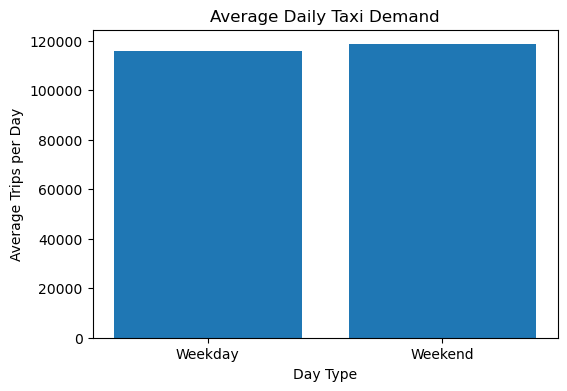

In [12]:
plt.figure(figsize=(6,4))

plt.bar(
    avg_daily["day_type"],
    avg_daily["trips"]
)

plt.title("Average Daily Taxi Demand")
plt.xlabel("Day Type")
plt.ylabel("Average Trips per Day")

plt.show()

#### Nhận xét:
- Trung bình số chuyến trong cuối tuần là 118.434 chuyến/ngày.
- Trung bình số chuyến trong ngày thường là 115.691 chuyến/ngày.
- Chênh lệch khoảng 2.743 chuyến/ngày, tương đương khoảng 2,4%.
- Nhu cầu sử dụng taxi vào cuối tuần cao hơn nhẹ so với các ngày trong tuần.

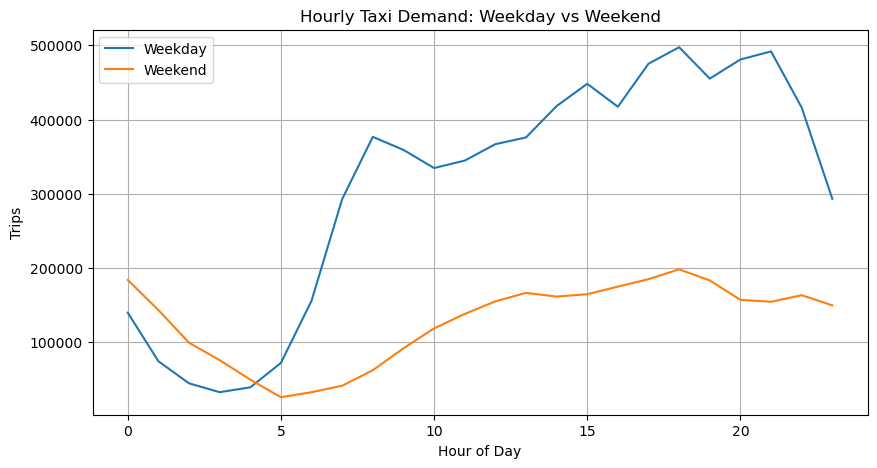

In [18]:
hour_pattern = (
    df.groupby(
        ["day_type","pickup_hour"]
    )
    .size()
    .reset_index(name="trips")
)
plt.figure(figsize=(10,5))

for t in ["Weekday","Weekend"]:
    temp = hour_pattern[
        hour_pattern["day_type"] == t
    ]

    plt.plot(
        temp["pickup_hour"],
        temp["trips"],
        label=t
    )

plt.title(
    "Hourly Taxi Demand: Weekday vs Weekend"
)

plt.xlabel("Hour of Day")
plt.ylabel("Trips")

plt.legend()
plt.grid()
plt.show()

In [23]:
df["pickup_date"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
).dt.date

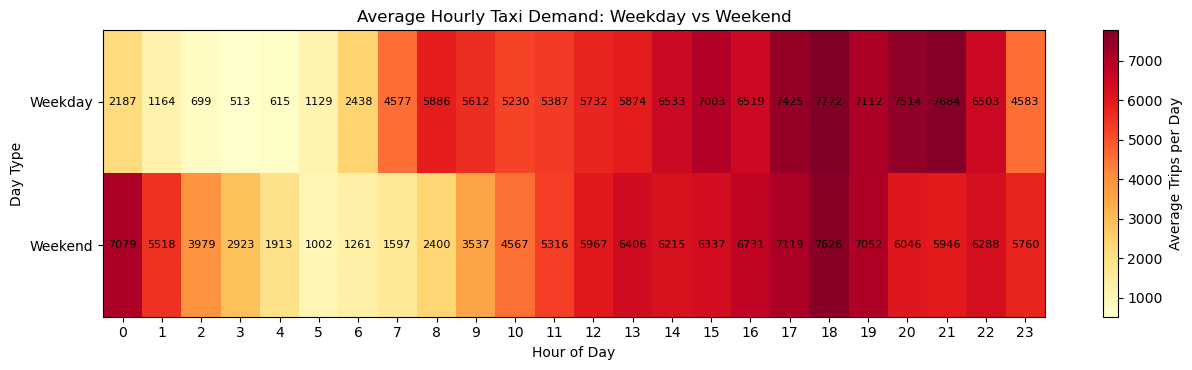

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# Average trips per hour
# ===========================

# Đếm số chuyến theo từng ngày, loại ngày và giờ
daily_hourly = (
    df.groupby(["pickup_date", "day_type", "pickup_hour"])
      .size()
      .reset_index(name="trips")
)

# Tính trung bình số chuyến của mỗi giờ
hour_pattern = (
    daily_hourly
    .groupby(["day_type", "pickup_hour"])["trips"]
    .mean()
    .reset_index()
)

# Pivot thành ma trận
heatmap_data = (
    hour_pattern
    .pivot(
        index="day_type",
        columns="pickup_hour",
        values="trips"
    )
    .reindex(["Weekday", "Weekend"])
)

# ===========================
# Plot Heatmap
# ===========================

fig, ax = plt.subplots(figsize=(13, 3.8))

im = ax.imshow(
    heatmap_data,
    cmap="YlOrRd",
    aspect="auto"
)

# Trục X
ax.set_xticks(np.arange(24))
ax.set_xticklabels(range(24))

# Trục Y
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Hiển thị giá trị trên từng ô
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.0f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Thanh màu
cbar = plt.colorbar(im)
cbar.set_label("Average Trips per Day")

# Tiêu đề
ax.set_title("Average Hourly Taxi Demand: Weekday vs Weekend")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day Type")

plt.tight_layout()
plt.show()

#### Nhận xét:
1. Xu hướng chung (Trend)
- Nhu cầu taxi của cả Weekday và Weekend đều giảm mạnh sau nửa đêm, sau đó tăng dần từ buổi sáng đến chiều.
- Tuy nhiên, Weekday có tốc độ tăng nhanh và mức dao động lớn hơn nhiều so với Weekend.
- Weekend có xu hướng ổn định hơn, không xuất hiện những đợt tăng đột biến.
2. Peak Hour
- Weekday: Các khung giờ 17:00–21:00 đều duy trì trên 475,000 chuyến, phản ánh một khoảng thời gian cao điểm kéo dài.
- Weekend: Khung giờ 17:00–19:00 là khoảng thời gian có nhu cầu cao nhất.
=> Mức nhu cầu cao nhất của Weekday cao hơn đáng kể so với Weekend
3. Off-Peak
Weekday: Giai đoạn 02:00–05:00 là khoảng thời gian có nhu cầu thấp nhất trong ngày.
Weekend: Khung giờ 03:00–06:00 là khoảng thời gian có nhu cầu thấp nhất trong ngày.
=> Cả hai nhóm đều có nhu cầu thấp nhất vào rạng sáng,
4. So sánh hai nhóm:
- Morning Commute: Nhu cầu tăng rất nhanh từ 06:00–08:00, phản ánh giờ cao điểm đi làm và đi học.
- Evening Commute: Sau buổi chiều, nhu cầu tiếp tục tăng và đạt đỉnh vào 18:00. Từ 17:00–21:00, lượng chuyến luôn ở mức rất cao, phù hợp với giờ tan làm, mua sắm và các hoạt động sau giờ hành chính.
- Late Night: Sau 21:00, nhu cầu bắt đầu giảm dần.

# Seasonal Pattern

In [32]:
df["pickup_date"] = (
    df["tpep_pickup_datetime"]
    .dt.date
)

daily_trips = (
    df
    .groupby("pickup_date")
    .size()
    .reset_index(name="trips")
)

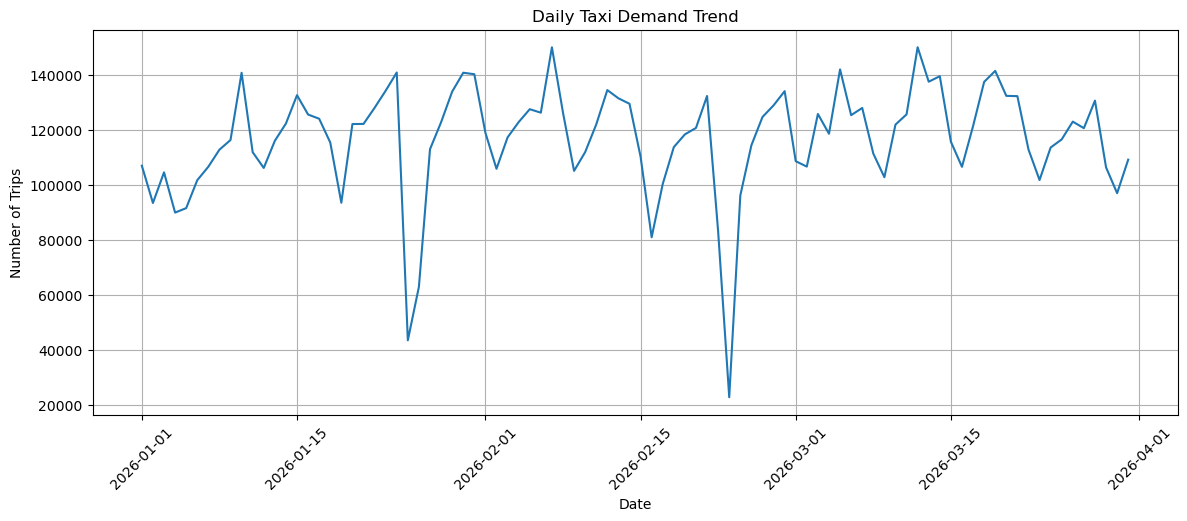

In [21]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_trips["pickup_date"],
    daily_trips["trips"]
)

plt.title("Daily Taxi Demand Trend")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.grid()

plt.show()

#### Nhận xét: 
1. Xu hướng chung:
Nhu cầu taxi trong giai đoạn từ tháng 1 đến tháng 3 không có xu hướng tăng hoặc giảm rõ rệt theo thời gian.
Đường xu hướng có nhiều biến động ngắn hạn giữa các ngày liên tiếp, phản ánh nhu cầu taxi chịu ảnh hưởng bởi các yếu tố thay đổi hàng ngày như lịch làm việc, thời tiết hoặc sự kiện.
2. Biến động theo ngày:
Nhu cầu taxi có sự dao động đáng kể giữa các ngày:
Một số ngày đạt mức cao khoảng 145,000 – 150,000 chuyến/ngày.
Một số ngày giảm mạnh xuống dưới 50,000 chuyến/ngày.
Các điểm giảm bất thường xuất hiện rõ rệt vào:
- Cuối tháng 1 
- Cuối tháng 2 
3. Giai đoạn nhu cầu cao:
Các giai đoạn có nhu cầu cao nhất đạt khoảng 140,000 – 150,000 chuyến/ngày.
Một số đỉnh nổi bật xuất hiện:
- Đầu tháng 2.
- Giữa tháng 3.
4. Giai đoạn nhu cầu thấp
Ngoài hai điểm giảm bất thường, phần lớn các ngày có nhu cầu duy trì trên 100,000 chuyến/ngày.
Các mức giảm sâu không xuất hiện thường xuyên, cho thấy hệ thống taxi vẫn duy trì nhu cầu ổn định trong toàn bộ giai đoạn.

### Ngày bất thường

In [ ]:
# Xác định các ngày bất thường
from scipy.stats import zscore

# Tính z-score cho số chuyến mỗi ngày
daily_trips["z_score"] = zscore(
    daily_trips["trips"]
)

# Lấy các ngày bất thường
anomalies = daily_trips[
    abs(daily_trips["z_score"]) > 3
]

anomalies

,tpep_pickup_datetime,trips,day_type,z_score
24,2026-01-25,43497,Weekend,-3.634867
53,2026-02-23,22814,Weekday,-4.664923


#### Nhận xét:
1. Với ngày 2026-01-25 tại New York City, điểm bất thường đến từ sự kiện thời tiết cực đoan. Sự kiện đáng chú ý nhất là: Major Winter Storm (Bão mùa đông lớn) tại New York City. Vào ngày 25/01/2026, New York City chịu ảnh hưởng của một trận bão mùa đông lớn. Cơ quan vệ sinh New York phát cảnh báo tuyết, dự báo lượng tuyết lớn và yêu cầu người dân hạn chế ra ngoài nếu không cần thiết.
2. Phân tích điểm bất thường ngày 23/02/2026
+ Số chuyến taxi ghi nhận: 22.814 chuyến
+ Nguyên nhân chính: do trận bão tuyết nghiêm trọng xảy ra tại New York vào ngày 23/02/2026. Do ảnh hưởng của thời tiết cực đoan: Chính quyền thành phố New York đã ban hành tình trạng khẩn cấp và hạn chế việc đi lại không cần thiết.
Nhiều tuyến đường, cầu và hệ thống giao thông bị hạn chế hoạt động để đảm bảo an toàn.
Tuyết rơi dày kèm theo gió mạnh khiến việc di chuyển trong thành phố trở nên khó khăn.
Người dân hạn chế ra ngoài, làm giảm nhu cầu sử dụng các phương tiện di chuyển như taxi.
Do đó, sự sụt giảm mạnh số lượng chuyến taxi trong ngày 23/02/2026 không phải là biến động ngẫu nhiên của dữ liệu mà có liên quan trực tiếp đến một yếu tố bên ngoài là điều kiện thời tiết khắc nghiệt.


### Holiday Effect

In [ ]:
#
holidays = [
    "2026-01-01",
    "2026-01-19",
    "2026-02-16",
]

daily_trips["holiday"] = (
    daily_trips["pickup_date"]
    .astype(str)
    .isin(holidays)
)

In [36]:
holiday_dates = [
    "2026-01-01",
    "2026-01-19",
    "2026-02-16",
]

holiday_trips = daily_trips[
    daily_trips["pickup_date"].astype(str).isin(holiday_dates)
]

holiday_trips

,pickup_date,trips,holiday
0,2026-01-01,106925,True
18,2026-01-19,93466,True


In [5]:
df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-01").date()
]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2564249,2,2026-01-01 23:14:51,2026-01-01 23:31:32,NaN,2.50,NaN,NaN,79,90,0,19.05,0.00,0.5,0.00,0.0,1.0,23.80,NaN,NaN,0.75
2564250,2,2026-01-01 23:49:53,2026-01-01 23:55:47,NaN,1.41,NaN,NaN,144,137,0,9.67,0.00,0.5,0.00,0.0,1.0,14.42,NaN,NaN,0.75
2564251,2,2026-01-01 23:12:18,2026-01-01 23:32:39,NaN,4.90,NaN,NaN,239,224,0,25.09,0.00,0.5,0.00,0.0,1.0,29.84,NaN,NaN,0.75
2564252,2,2026-01-01 23:18:43,2026-01-01 23:27:46,NaN,1.25,NaN,NaN,75,41,0,12.09,0.00,0.5,0.00,0.0,1.0,15.59,NaN,NaN,0.00


In [7]:
df_newyear = df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-01").date()
]

df_newyear["hour"] = (
    df_newyear["tpep_pickup_datetime"]
    .dt.hour
)

df_newyear["hour"].value_counts().sort_index()

C:\Users\Linh\AppData\Local\Temp\ipykernel_17572\4076752593.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_newyear["hour"] = (


hour
0     9031
1     9911
2     7523
3     6300
4     3940
5     2124
6     2029
7     1869
8     1649
9     2176
10    3063
11    4149
12    5077
13    5216
14    5423
15    5983
16    4743
17    4552
18    4272
19    4055
20    4121
21    3885
22    3249
23    2585
Name: count, dtype: int64

In [8]:
df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-19").date()
]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1490858,2,2026-01-19 00:09:48,2026-01-19 00:20:26,1.0,1.90,1.0,N,230,236,1,12.10,1.0,0.5,3.57,0.00,1.0,21.42,2.5,0.00,0.75
1490859,2,2026-01-19 00:00:19,2026-01-19 00:18:24,1.0,9.87,1.0,N,138,229,1,38.00,6.0,0.5,14.05,7.46,1.0,72.01,2.5,1.75,0.75
1490860,2,2026-01-19 00:26:29,2026-01-19 00:37:14,3.0,2.26,1.0,N,161,249,1,12.80,1.0,0.5,1.86,0.00,1.0,20.41,2.5,0.00,0.75
1490861,2,2026-01-19 00:34:35,2026-01-19 00:51:14,1.0,3.11,1.0,N,232,68,1,18.40,1.0,0.5,3.62,0.00,1.0,27.77,2.5,0.00,0.75
1490862,2,2026-01-19 00:57:25,2026-01-19 01:29:04,2.0,7.06,1.0,N,246,37,1,34.50,1.0,0.5,7.00,0.00,1.0,47.25,2.5,0.00,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3072812,2,2026-01-19 23:10:52,2026-01-19 23:27:52,NaN,5.47,NaN,NaN,164,87,0,32.32,0.0,0.5,0.00,0.00,1.0,42.68,NaN,NaN,0.75
3072813,2,2026-01-19 23:37:40,2026-01-20 00:03:14,NaN,9.67,NaN,NaN,87,238,0,34.18,0.0,0.5,0.00,0.00,1.0,38.93,NaN,NaN,0.75
3072814,2,2026-01-19 23:23:47,2026-01-19 23:46:52,NaN,4.45,NaN,NaN,74,48,0,19.21,0.0,0.5,0.00,0.00,1.0,23.96,NaN,NaN,0.75
3072815,2,2026-01-19 23:31:20,2026-01-19 23:41:22,NaN,1.69,NaN,NaN,224,90,0,13.08,0.0,0.5,0.00,0.00,1.0,17.83,NaN,NaN,0.75


In [9]:
df_Martin = df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-19").date()
]

df_Martin["hour"] = (
    df_Martin["tpep_pickup_datetime"]
    .dt.hour
)

df_Martin["hour"].value_counts().sort_index()

C:\Users\Linh\AppData\Local\Temp\ipykernel_17572\906725578.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Martin["hour"] = (


hour
0     3403
1     1786
2     1066
3      807
4      796
5      881
6     1406
7     1876
8     2879
9     3846
10    4569
11    5324
12    5899
13    5874
14    6887
15    6869
16    5846
17    5502
18    5767
19    5227
20    5115
21    4755
22    3720
23    3366
Name: count, dtype: int64

In [13]:
# Presidents' Day (Washington's Birthday) — 16/02/2026 (Thứ Hai)
df_presidents = df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-02-16").date()
]

df_presidents["hour"] = (
    df_presidents["tpep_pickup_datetime"]
    .dt.hour
)

df_presidents["hour"].value_counts().sort_index()

C:\Users\Linh\AppData\Local\Temp\ipykernel_512\2919806687.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_presidents["hour"] = (


hour
0     3087
1     1767
2     1056
3      831
4      818
5      771
6     1296
7     1606
8     2494
9     3087
10    3757
11    4384
12    4711
13    5154
14    5446
15    5583
16    5013
17    5416
18    5362
19    4598
20    4426
21    4445
22    3399
23    2413
Name: count, dtype: int64

### Phân bố theo giờ — 3 ngày lễ

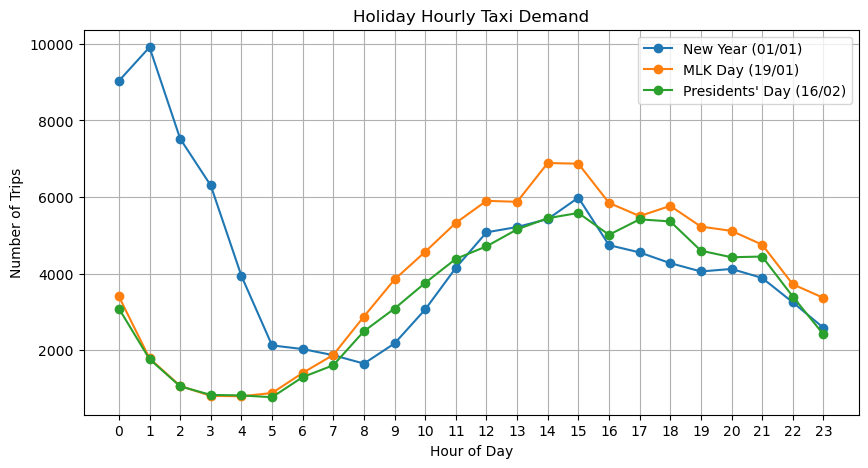

In [15]:
# Biểu đồ theo giờ của 3 ngày lễ
import matplotlib.pyplot as plt

holiday_map = {
    "New Year (01/01)":        "2026-01-01",
    "MLK Day (19/01)":         "2026-01-19",
    "Presidents' Day (16/02)": "2026-02-16",
}

plt.figure(figsize=(10, 5))

for label, date in holiday_map.items():
    day = df[df["tpep_pickup_datetime"].dt.date == pd.to_datetime(date).date()]
    hourly = (
        day["tpep_pickup_datetime"].dt.hour
        .value_counts()
        .reindex(range(24), fill_value=0)
        .sort_index()
    )
    plt.plot(hourly.index, hourly.values, marker="o", label=label)

plt.title("Holiday Hourly Taxi Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

#### Nhận xét:
1. Ngày 01/01/2026 – New Year's Day (Thứ Năm)
- Loại ngày: Holiday
- Số chuyến taxi: 106.925 chuyến
- Nhận xét phân bố theo giờ – 01/01/2026: 
    + Nhu cầu rất cao vào rạng sáng (00:00–02:00)
    + 00:00: 9.031 chuyến
    + 01:00: 9.911 chuyến (cao nhất trong ngày)
    + 02:00: 7.523 chuyến

=> Giải thích: Người dân di chuyển sau các hoạt động đón giao thừa (New Year's Eve).
→ Taxi đóng vai trò quan trọng trong việc di chuyển an toàn sau khi tham gia các hoạt động ban đêm.
- Giảm mạnh vào buổi sáng (05:00–09:00)
    + 05:00: 2.124 chuyến
    + 06:00: 2.029 chuyến
    + 07:00: 1.869 chuyến
    + 08:00: 1.649 chuyến (thấp nhất ngày)

=> Giải thích: Ngày lễ nên: Người dân nghỉ làm, trường học đóng cửa. Không có nhu cầu đi làm vào giờ cao điểm.
2. Ngày 19/01/2026 – Martin Luther King Jr. Day (Thứ Hai)
- Loại ngày: Ngày lễ (Holiday)
- Tổng số chuyến taxi: 93.466 chuyến
- Nhu cầu rất thấp vào rạng sáng (01:00–06:00). Số chuyến theo giờ:
    + 01:00: 1.786 chuyến
    + 02:00: 1.066 chuyến
    + 03:00: 807 chuyến
    + 04:00: 796 chuyến (thấp nhất trong ngày)
    + 05:00: 881 chuyến
- Giảm mạnh nhu cầu đi lại buổi sáng. Trong ngày thường, New York thường có giờ cao điểm buổi sáng do người dân đi làm: Tuy nhiên, ngày 19/01:
    + 07:00: 1.876
    + 08:00: 2.879
    + 09:00: 3.846

=> Giải thích: Ngày 19/01 là Martin Luther King Jr. Day, một ngày nghỉ liên bang: Nhiều công ty đóng cửa, trường học nghỉ, người lao động không cần di chuyển đến nơi làm việc.
- Nhu cầu tăng cao vào buổi chiều (12:00–16:00):
    + Các khung giờ có nhiều chuyến nhất. Đỉnh cao nhất: 
    + 14:00: 6.887 chuyến
    + 15:00: 6.869 chuyến

=> Giải thích: Trong ngày nghỉ, hành vi di chuyển thay đổi: Người dân đi mua sắm, đi ăn uống, đi thăm gia đình, bạn bè, tham gia các hoạt động cá nhân. Do đó, nhu cầu taxi chuyển từ đi làm sang đi lại phục vụ cá nhân và giải trí.

3. Ngày 16/02/2026 – Presidents' Day / Washington's Birthday (Thứ Hai)
- Loại ngày: Ngày lễ liên bang (Holiday)
- Tổng số chuyến taxi: 80.920 chuyến (thấp hơn ~12% so với thứ Hai thường ~91.697)
- Rạng sáng rất vắng: thấp nhất khoảng 05:00 (~771 chuyến), do không có nhu cầu đi làm sớm.
- Mất cao điểm sáng, nhu cầu dồn về buổi chiều 13:00–18:00 (đỉnh ~15:00 với 5.583 chuyến).

=> Ngày nghỉ khiến nhu cầu chuyển từ đi làm sang đi lại phục vụ cá nhân, giải trí vào buổi chiều — Holiday ảnh hưởng đến hành vi di chuyển, không chỉ tổng lượng chuyến.


=> Holiday ảnh hưởng đến hành vi của con người


In [25]:
df["pickup_month"] = (
    df["tpep_pickup_datetime"]
    .dt.to_period("M")
)

monthly_trips = (
    df
    .groupby("pickup_month")
    .size()
)

In [6]:
# Trung bình số chuyến/ngày của mỗi tháng
monthly_avg = monthly_trips.reset_index(name="trips")

monthly_avg["days_in_month"] = (
    monthly_avg["pickup_month"].dt.days_in_month
)

monthly_avg["trips_per_day"] = (
    (monthly_avg["trips"] / monthly_avg["days_in_month"])
    .round(0)
    .astype(int)
)

print(monthly_avg)

  pickup_month    trips  days_in_month  trips_per_day
0      2026-01  3514777             31         113380
1      2026-02  3208379             28         114585
2      2026-03  3760341             31         121301


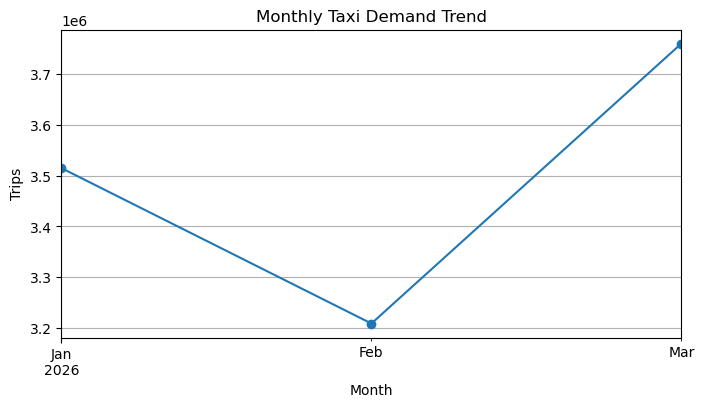

In [26]:
plt.figure(figsize=(8,4))

monthly_trips.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Taxi Demand Trend"
)

plt.xlabel("Month")
plt.ylabel("Trips")

plt.grid()

plt.show()

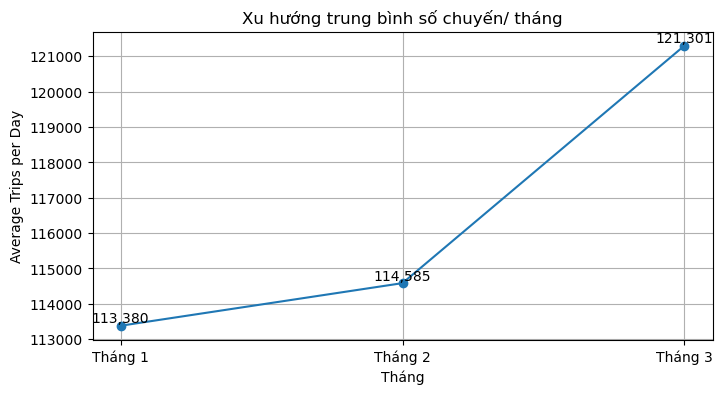

In [13]:
# Xu hướng trung bình số chuyến/ngày theo tháng
month_labels = "Tháng " + monthly_avg["pickup_month"].dt.month.astype(str)

plt.figure(figsize=(8, 4))

plt.plot(
    month_labels,
    monthly_avg["trips_per_day"],
    marker="o"
)

# Ghi giá trị tại mỗi điểm
for x, y in zip(month_labels, monthly_avg["trips_per_day"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

plt.title("Xu hướng trung bình số chuyến/ tháng")
plt.xlabel("Tháng")
plt.ylabel("Average Trips per Day")

plt.grid()

plt.show()

#### Nhận xét:

**Tổng số chuyến theo tháng:**
- Tháng 1: ~3,51 triệu chuyến
- Tháng 2: ~3,21 triệu chuyến (thấp nhất)
- Tháng 3: ~3,76 triệu chuyến (cao nhất)

**Trung bình số chuyến/ngày:**
- Tháng 1: ~113.380 chuyến/ngày (thấp nhất)
- Tháng 2: ~114.585 chuyến/ngày
- Tháng 3: ~121.301 chuyến/ngày (cao nhất)

**Kết luận:**
- Tháng 2 có **tổng** số chuyến thấp nhất, nguyên nhân chính là tháng 2 chỉ có 28 ngày so với 31 ngày của tháng 1 và tháng 3. Bên cạnh yếu tố số ngày, tháng 2 còn có **một ngày bất thường 23/02** (chỉ 22.814 chuyến, hụt ~97.000 chuyến so với ngày thường — do bão tuyết). 
- Tháng 3 là tháng có nhu cầu cao nhất(~121K/ngày). Điều này cho thấy nhu cầu di chuyển tăng sau tháng 2, phản ánh điều kiện thời tiết thuận lợi hơn và hoạt động đi lại sôi động hơn khi bước sang đầu mùa xuân.